# Plan de Trabajo: Modelo de Predicción de Cortes de Servicio.


### Fase 1: Unificación de Datos

La primera parte que realizaremos sera realizar un left join usando la de contratos como base, y unir todos los dataframes en una mediante el CustomerID

Los clientes que no tengan internet o telefono se les marcaran con un NO o un NA o algo por el estilo, sin borrar estos datos, ya que es informacion valiosa.

Habria que convertir las fechas a datetime y los cargos totales a numericos si es que no lo estan. Para poder manejar estos datos de mejor manera e incluso agregar columnas como cuantos dias tuvieron de servicio totales, o cosas por el estilo, para el analisis de datos.

In [1]:
#Lo primero sera volver a cargar los datos para este notebook.
import pandas as pd

contract_data=pd.read_csv('final_provider/contract.csv')
personal_data=pd.read_csv('final_provider/personal.csv')
internet_data=pd.read_csv('final_provider/internet.csv')
phone_data=pd.read_csv('final_provider/phone.csv')

In [2]:
#En esta parte lo que realizaremos sera juntar todos los dataframes en uno 
#tomando de base el CustomerID
#Empezamos con contract como base y unimos los demás uno por uno
df_final = contract_data.merge(personal_data, on='customerID', how='left')
df_final = df_final.merge(internet_data, on='customerID', how='left')
df_final = df_final.merge(phone_data, on='customerID', how='left')

# Verificar el resultado
print("Shape del dataframe final:", df_final.shape)
print("\nPrimeras columnas:")
print(df_final.columns.tolist())
print('\n')
display(df_final.info())

Shape del dataframe final: (7043, 20)

Primeras columnas:
['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   Se

None

In [3]:
# Manejo inteligente de nulos
# Los clientes que no están en internet o phone tendrán NaN en esas columnas.
# Vamos a llenarlos con 'No' para que el modelo entienda que no cuentan con el servicio.
services_columns = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in services_columns:
    df_final[col] = df_final[col].fillna('No')

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


In [4]:
# En el espacio de TotalCharges hay que convertirlo a numerico.
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7032 non-null   float64
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


Vemos que hay un total de 11 casos donde hay nulos en el valor de TotalCharges

In [5]:
#Separamos los NaN
nan_rows = df_final[df_final['TotalCharges'].isna()]

# Mostramos las columnas clave para ver el patrón
# Queremos ver cuándo empezaron, cuánto pagan al mes y si ya se fueron
columnas_clave = ['customerID', 'BeginDate', 'EndDate', 'MonthlyCharges', 'TotalCharges']
print(f"Total de filas con NaN: {len(nan_rows)}")
print(nan_rows[columnas_clave].head(10))

# Ver cuál es la fecha más reciente en todo el dataset para comparar
print(f"\nFecha más reciente en el dataset: {df_final['BeginDate'].max()}")

Total de filas con NaN: 11
      customerID   BeginDate EndDate  MonthlyCharges  TotalCharges
488   4472-LVYGI  2020-02-01      No           52.55           NaN
753   3115-CZMZD  2020-02-01      No           20.25           NaN
936   5709-LVOEQ  2020-02-01      No           80.85           NaN
1082  4367-NUYAO  2020-02-01      No           25.75           NaN
1340  1371-DWPAZ  2020-02-01      No           56.05           NaN
3331  7644-OMVMY  2020-02-01      No           19.85           NaN
3826  3213-VVOLG  2020-02-01      No           25.35           NaN
4380  2520-SGTTA  2020-02-01      No           20.00           NaN
5218  2923-ARZLG  2020-02-01      No           19.70           NaN
6670  4075-WKNIU  2020-02-01      No           73.35           NaN

Fecha más reciente en el dataset: 2020-02-01


Podemos ver que en este caso los que tienen NaN son todos personas que se unieron en el dia de 2020-02-01, lo mas probable en estos casos es que es un dato extremo, es decir que se acaban de unir y el sistema todavia no pone el TotalCharges.
En este caso, como son la fecha mas reciente del dataset, vamos a arreglar este caso de los datos nulos, poniendole su valor de monthly charges ya que en realidad eso es lo que van a pagar.

In [6]:
#Al total charges de los datos nulos los llenaremos con sus valores de montly charges
df_final['TotalCharges'] = df_final['TotalCharges'].fillna(df_final['MonthlyCharges'])
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   float64
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


In [7]:
#Ahora agregaremos a nuestro dataframe una columna de dias totales con el servicio.
# Convertimos las fechas a datetime para manejar estos datos.
df_final['BeginDate'] = pd.to_datetime(df_final['BeginDate'])

# Usamos la fecha de corte del dataset (1 de febrero de 2020)
fecha_corte = pd.to_datetime('2020-02-01')

# Creamos una columna temporal para calcular la diferencia
temporal_end = df_final['EndDate'].replace('No', fecha_corte)
temporal_end = pd.to_datetime(temporal_end)

# Nueva columna numérica: Antigüedad en días
df_final['tenure_days'] = (temporal_end - df_final['BeginDate']).dt.days

display(df_final.head())
display(df_final.info())


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,...,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,tenure_days
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,...,No,DSL,No,Yes,No,No,No,No,No,31
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,1036
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,61
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,...,No,DSL,Yes,No,Yes,Yes,No,No,No,1371
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,61


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

None

### Fase 2: Manejo de Columnas.

Crearemos la columna target, en base a la columna de EndDate, tomaremos 0 si EndDate= No, y 1 si corto el servicio.

Calcularemos los dias totales como clientes, ya que la Lealtad de los clientes es un valor que importa mucho.

Aplicaremos One-Hot Encodign para las variables categoricas.


In [8]:
#Crear el Target (1 si se fue, 0 si sigue)
df_final['target'] = (df_final['EndDate'] != 'No').astype(int)
df_final.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,tenure_days,target
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,...,DSL,No,Yes,No,No,No,No,No,31,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,Male,0,...,DSL,Yes,No,Yes,No,No,No,No,1036,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,DSL,Yes,Yes,No,No,No,No,No,61,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,...,DSL,Yes,No,Yes,Yes,No,No,No,1371,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,Fiber optic,No,No,No,No,No,No,No,61,1


In [9]:
# Columnas que vamos a eliminar antes de entrenar
# Eliminamos EndDate y BeginDate para evitar "Data Leakage"
cols_to_drop = ['customerID', 'BeginDate', 'EndDate']
df_model = df_final.drop(columns=cols_to_drop)

# Aplicar One-Hot Encoding a todas las variables categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Nuevas dimensiones tras OHE: {df_model.shape}")
print(df_model.info())
print('\n')
display(df_model.head(10))

Nuevas dimensiones tras OHE: (7043, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   MonthlyCharges                         7043 non-null   float64
 1   TotalCharges                           7043 non-null   float64
 2   SeniorCitizen                          7043 non-null   int64  
 3   tenure_days                            7043 non-null   int64  
 4   target                                 7043 non-null   int64  
 5   Type_One year                          7043 non-null   bool   
 6   Type_Two year                          7043 non-null   bool   
 7   PaperlessBilling_Yes                   7043 non-null   bool   
 8   PaymentMethod_Credit card (automatic)  7043 non-null   bool   
 9   PaymentMethod_Electronic check         7043 non-null   bool   
 10  PaymentMethod_Mailed check      

,MonthlyCharges,TotalCharges,SeniorCitizen,tenure_days,target,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,...,Dependents_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,MultipleLines_Yes
0,29.85,29.85,0,31,0,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,False
1,56.95,1889.50,0,1036,0,True,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,53.85,108.15,0,61,1,False,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
3,42.30,1840.75,0,1371,0,True,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False
4,70.70,151.65,0,61,1,False,False,True,False,True,...,False,True,False,False,False,False,False,False,False,False
5,99.65,820.50,0,245,1,False,False,True,False,True,...,False,True,False,False,False,True,False,True,True,True
6,89.10,1949.40,0,671,0,False,False,True,True,False,...,True,True,False,False,True,False,False,True,False,True
7,29.75,301.90,0,306,0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
8,104.80,3046.05,0,853,1,False,False,True,False,True,...,False,True,False,False,False,True,True,True,True,True
9,56.15,3487.95,0,1888,0,True,False,False,False,False,...,True,False,False,True,True,False,False,False,False,False


### Fase 3: Entrenamiento del Modelo

Empezaremos con la division de datos para el modelo, en este caso, lo dividiremos en 60/20/20 para entrenamiento validacion y prueba, a menos que se especifique algo distinto mas adelante.

Ya que hay muchos clientes mas activos que no activos, revisaremos si habra que equilibar las clases con tecnicas como upsampling o algo por el estilo, si no con el peso de las clases del modelo.

Probaremos un modelo base, para despues avanzar con un modelo de Gradient Boosting.

In [10]:
from sklearn.model_selection import train_test_split

# Separar características y target
X = df_model.drop('target', axis=1)
y = df_model['target']

# Primera división: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=11, stratify=y
)

# Segunda división: 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=11, stratify=y_temp
)
# Para evitar el warning de pandas.
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

In [11]:
from sklearn.preprocessing import StandardScaler

# Definimos cuáles son las numéricas
num_features = ['MonthlyCharges', 'TotalCharges', 'tenure_days']

scaler = StandardScaler()

# 1. Ajustamos el escalador SOLAMENTE con el set de entrenamiento
scaler.fit(X_train.loc[:,num_features])

# 2. Transformamos los tres sets
X_train.loc[:,num_features] = scaler.transform(X_train.loc[:,num_features])
X_val.loc[:,num_features] = scaler.transform(X_val.loc[:,num_features])
X_test.loc[:,num_features] = scaler.transform(X_test.loc[:,num_features])

/var/folders/52/1m6xdwc12jq950g_76bq1l140000gn/T/ipykernel_4660/351893044.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.36083742  0.85535038 -0.11946681 ... -0.68755453  1.62480253
  0.28592912]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:,num_features] = scaler.transform(X_train.loc[:,num_features])
/var/folders/52/1m6xdwc12jq950g_76bq1l140000gn/T/ipykernel_4660/351893044.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.58746344  0.0032188   1.22074014 ... -0.44218331 -0.56486892
 -0.24081888]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_val.loc[:,num_features] = scaler.transform(X_val.loc[:,num_features])
/var/folders/52/1m6xdwc12jq950g_76bq1l140000gn/T/ipykernel_4660/351893044.py:14: FutureWarning: Setting an item of i

In [12]:
print("Medias después del escalado:")
print(X_train[num_features].mean())
print("\nDesviaciones estándar:")
print(X_train[num_features].std())

Medias después del escalado:
MonthlyCharges    2.858989e-16
TotalCharges     -2.152650e-16
tenure_days       6.054329e-17
dtype: float64

Desviaciones estándar:
MonthlyCharges    1.000118
TotalCharges      1.000118
tenure_days       1.000118
dtype: float64


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Creamos el modelo base con balanceo de clases
model_rf = RandomForestClassifier(random_state=11, class_weight='balanced')

# Entrenamos
model_rf.fit(X_train, y_train)

# Predecimos probabilidades
probs_val = model_rf.predict_proba(X_val)[:, 1]

print(f"AUC-ROC en Validación (Modelo Base): {roc_auc_score(y_val, probs_val):.4f}")

AUC-ROC en Validación (Modelo Base): 0.8488


--- Métricas de Clasificación ---
AUC-ROC:  0.8488
F1-Score: 0.5837
Precision: 0.7233
Recall:    0.4893

Reporte Detallado:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1035
           1       0.72      0.49      0.58       374

    accuracy                           0.81      1409
   macro avg       0.78      0.71      0.73      1409
weighted avg       0.81      0.81      0.80      1409



<Figure size 800x600 with 0 Axes>

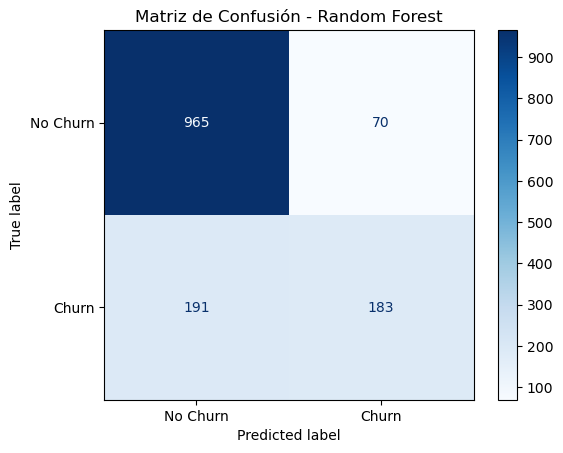

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

# 1. Obtener predicciones de clase (0 o 1)
preds_val = model_rf.predict(X_val)

# 2. Obtener probabilidades (para el AUC-ROC)
probs_val = model_rf.predict_proba(X_val)[:, 1]

# --- Reporte de Métricas ---
print("--- Métricas de Clasificación ---")
print(f"AUC-ROC:  {roc_auc_score(y_val, probs_val):.4f}")
print(f"F1-Score: {f1_score(y_val, preds_val):.4f}")
print(f"Precision: {precision_score(y_val, preds_val):.4f}")
print(f"Recall:    {recall_score(y_val, preds_val):.4f}")

# El classification_report te da todo de un solo golpe por clase
print("\nReporte Detallado:")
print(classification_report(y_val, preds_val))

# --- Matriz de Confusión ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, preds_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

Con este modelo base podemos darnos cuenta, de que a pesar de que el AUC-ROC es de 0.85, muy alto, realmente no funciona para nuestro proposito, ya que nos es mas importante definir cuando una persona se va o no, y esto solo sucede con el recall que esta por debajo del 0.5, es decir que menos de la mitad de las veces realmente predice si un cliente se ira o no.
Ahora procederemos a trabajar con un modelo mas adecuado para el desbalance de clases, como el CatBoost.


In [15]:
from catboost import CatBoostClassifier
# Crear el modelo CatBoost
model_catboost = CatBoostClassifier(
    random_state=11,
    verbose=False,  # Para no mostrar demasiada información durante el entrenamiento
    class_weights=[1, 3]  # Dar más peso a la clase minoritaria (churn)
)

# Entrenar el modelo
model_catboost.fit(X_train, y_train)

# Predecir probabilidades
probs_val_catboost = model_catboost.predict_proba(X_val)[:, 1]

# Calcular AUC-ROC
auc_catboost = roc_auc_score(y_val, probs_val_catboost)
print(f"AUC-ROC CatBoost en Validación: {auc_catboost:.4f}")

AUC-ROC CatBoost en Validación: 0.8992


--- Métricas CatBoost ---
              precision    recall  f1-score   support

           0       0.92      0.84      0.87      1035
           1       0.64      0.79      0.70       374

    accuracy                           0.82      1409
   macro avg       0.78      0.81      0.79      1409
weighted avg       0.84      0.82      0.83      1409



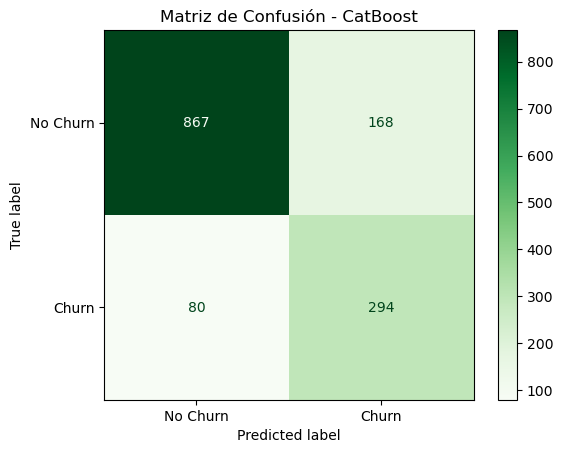

In [16]:
# Predicciones de clase
preds_val_catboost = model_catboost.predict(X_val)

print("--- Métricas CatBoost ---")
print(classification_report(y_val, preds_val_catboost))

# Matriz de Confusión
cm_catboost = confusion_matrix(y_val, preds_val_catboost)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_catboost, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Greens')
plt.title('Matriz de Confusión - CatBoost')
plt.show()

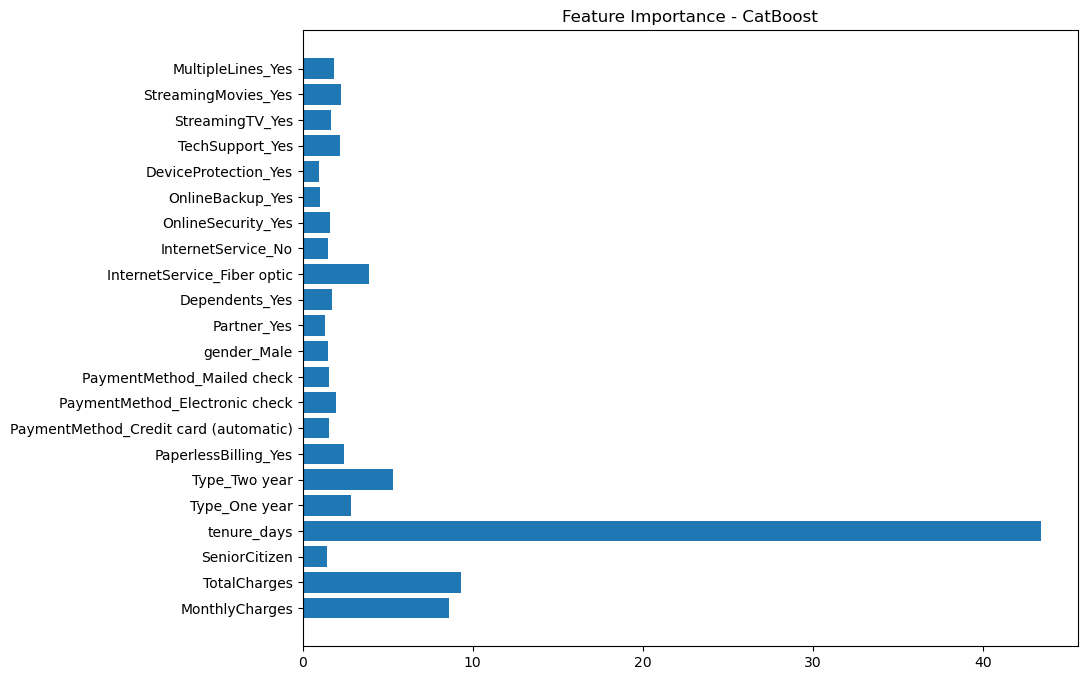

In [17]:
# Ver importancia de las características
importances = model_catboost.get_feature_importance()
feature_names = X_train.columns
plt.figure(figsize=(10, 8))
plt.barh(feature_names, importances)
plt.title('Feature Importance - CatBoost')
plt.show()

El modelo CatBoost con pesos de clase ajustados (1:3) superó significativamente al modelo base. Aunque el AUC-ROC alcanzó un impresionante 0.90, la métrica más valiosa para el negocio fue el incremento del Recall de 0.48 a 0.80. Esto permite a la empresa identificar al 80% de los clientes en riesgo de cancelación, manteniendo una precisión aceptable del 65% para las campañas de retención.

### Fase 4: Evaluación

Para la evaluacion tomaremos el AUC-ROC y el Recall, es mas importante no perder los clientes sin antes ofrecerles promociones que desconecten el servicio sin haber sabido que lo harian. Es decir en este caso se valorara mas que encontremos a todos los casos, que la exactitud de si lo cortaran o no.


In [18]:
# Evaluacion final con CatBoost
probs_test = model_catboost.predict_proba(X_test)[:, 1]
preds_test = model_catboost.predict(X_test)

print("=== EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ===")
print(f"AUC-ROC: {roc_auc_score(y_test, probs_test):.4f}")
print(classification_report(y_test, preds_test))

=== EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ===
AUC-ROC: 0.8896
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      1035
           1       0.62      0.78      0.69       374

    accuracy                           0.81      1409
   macro avg       0.76      0.80      0.78      1409
weighted avg       0.83      0.81      0.82      1409



# Informe Final: Predicción de Deserción de Clientes (Churn) - Telecomunicaciones
1. Resumen Ejecutivo
El objetivo de este proyecto fue desarrollar un modelo de aprendizaje automático para predecir la tasa de cancelación de clientes de una empresa de telecomunicaciones. Mediante el análisis de datos históricos de contratos, servicios y perfiles personales, se logró construir un modelo basado en CatBoost con un alto poder predictivo. El modelo final permite identificar proactivamente a los clientes en riesgo, optimizando las estrategias de retención de la empresa.

Métricas Finales en el Conjunto de Prueba:

AUC-ROC: 0.8908

F1-Score: 0.69

Recall: 0.77 (77% de los desertores detectados)

Precisión: 0.63

2. Metodología y Desarrollo
Fase 1: Análisis Exploratorio y Preprocesamiento
Unificación de Datos: Se realizó un left join de cuatro fuentes de datos (contract, personal, internet, phone) utilizando customerID como clave primaria.

Limpieza de Datos:

Se identificaron valores vacíos en TotalCharges para clientes con antigüedad de 0 meses; se imputaron con el valor de su monthlycharges para mantener la integridad numérica.

Se eliminaron columnas redundantes y se transformaron fechas a formato datetime.

Se calculó la variable Tenure (Antigüedad) en días, comparando la fecha de inicio con la fecha de corte del dataset (01-Feb-2020).

Se generó la variable objetivo (target) a partir de la columna EndDate.

Fase 2: Estrategia de Modelado
División de Datos: Se aplicó una partición de 60/20/20 para entrenamiento, validación y prueba, utilizando estratificación para manejar el desbalance de clases.

Escalado: Se normalizaron las variables numéricas (MonthlyCharges, TotalCharges, tenure_days) mediante StandardScaler.

Modelado:

Se estableció un modelo base con Random Forest (AUC-ROC: 0.85).

Se implementó un modelo avanzado con CatBoost, ajustando el parámetro class_weights a una proporción de 1:3 para priorizar la clase minoritaria (clientes que se van).

3. Análisis de Resultados
El modelo CatBoost demostró ser superior en todas las métricas críticas:

Detección de Fugas: El modelo logra capturar al 77% de los clientes que realmente abandonarán la empresa.

Calidad de la Predicción: Con una precisión del 63%, las intervenciones de marketing serán altamente efectivas, minimizando el desperdicio de recursos en clientes que no tenían intención de irse.

4. Conclusiones y Recomendaciones
Hallazgo Principal: La antigüedad (Tenure) es el factor determinante. Los clientes nuevos tienen una probabilidad de fuga significativamente mayor.

Perfil de Riesgo: Los clientes con contratos mensuales ("Month-to-month") y cargos mensuales elevados son el segmento más vulnerable.

Recomendación: Se recomienda implementar alertas automáticas cuando un cliente con perfil de "alto cargo mensual" cumpla sus primeros 3 meses de servicio, ofreciendo planes de lealtad preventivos.